In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# setting up parameters
N       = 100    # Number of lattice sites (spatial dimension)
T       = 300    # Number of time steps
r       = 4.0    # Logistic map parameter (r=4 → full chaos)
epsilon = 0.3    # Coupling strength (0 = no coupling, 1 = max coupling)

In [3]:
# Initial conditions
np.random.seed(42)            # Makes the randomness reproducible
                              # Same seed = same "random" numbers every run
                              # Remove this if you want different runs each time

x = np.random.rand(N)         # Each of the 100 sites gets a random starting
                              # value between 0 and 1
                              # x is now an array: [0.37, 0.95, 0.73, ...]
                              #                     site0  site1  site2

In [4]:
# The logistic map
def logistic(x, r):
    return r * x * (1 - x)

In [5]:
# Storage

history = np.zeros((T, N))
history[0] = x  # Store initial state in the first row of history

In [7]:
# Time evolution
for t in range(1, T):
    fx       = logistic(x, r)              # map every site
    fx_left  = np.roll(fx,  1)             # left neighbor's mapped value
    fx_right = np.roll(fx, -1)             # right neighbor's mapped value
    x        = (1 - epsilon) * fx + (epsilon / 2) * (fx_left + fx_right)
    history[t] = x

print("Done. history.shape =", history.shape)


Done. history.shape = (300, 100)


In [8]:
print("Min value:", history.min())   # should be close to 0
print("Max value:", history.max())   # should be close to 1
print("Sample row (t=0):", history[0, :5])   # your initial conditions
print("Sample row (t=1):", history[1, :5])   # first update

Min value: 0.005522117123602399
Max value: 0.9996405670782567
Sample row (t=0): [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
Sample row (t=1): [0.47494332 0.90161016 0.8944059  0.43788685 0.18431169]


##### Plots

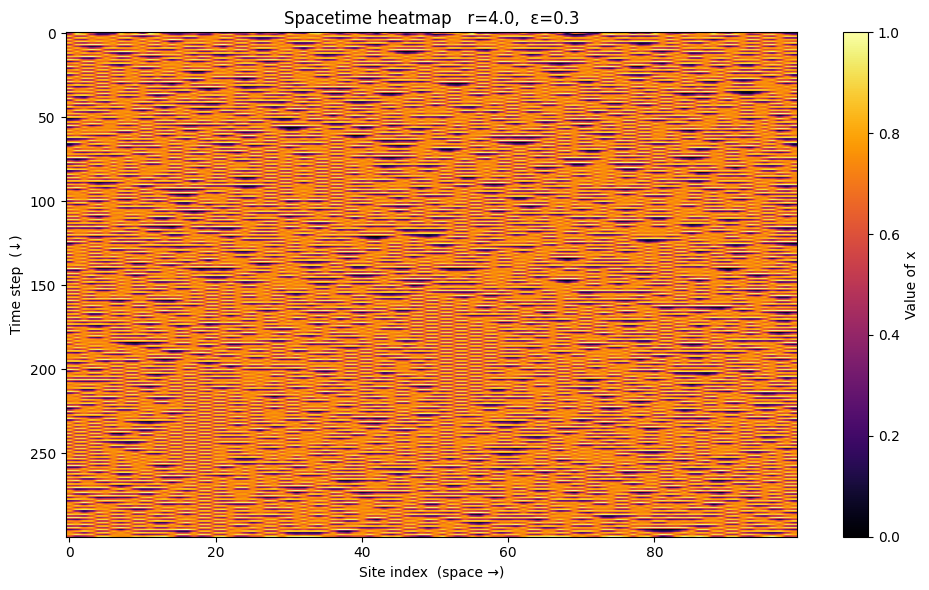

In [11]:
# The space time heat map
plt.figure(figsize=(10, 6))

plt.imshow(
    history,          # the full T×N array
    aspect='auto',    # don't force square pixels — stretch to fit
    cmap='inferno',# color scheme: black→red→yellow→white
    origin='upper',   # t=0 at the top, time flows downward
    vmin=0, vmax=1    # fix color scale: 0 is always black, 1 always white
)

plt.colorbar(label='Value of x')
plt.xlabel('Site index  (space →)')
plt.ylabel('Time step  (↓)')
plt.title(f'Spacetime heatmap   r={r},  ε={epsilon}')
plt.tight_layout()
plt.show()

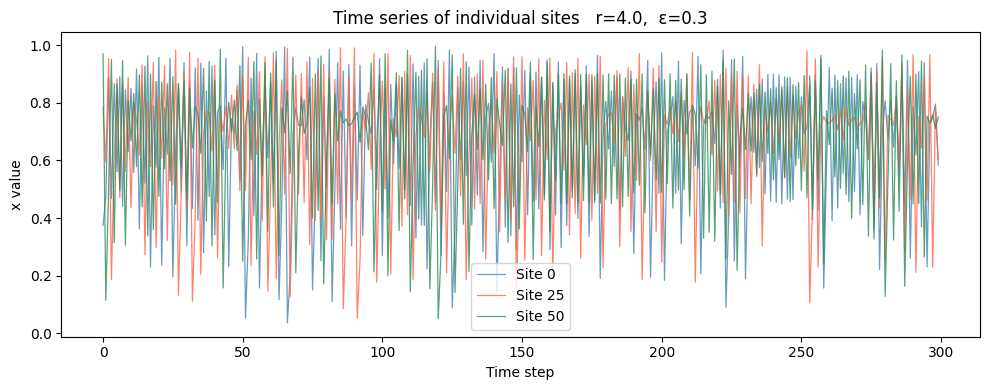

In [12]:
# Single site time series
plt.figure(figsize=(10, 4))

# Plot 3 different sites on the same graph
sites_to_plot = [0, N//4, N//2]     # sites 0, 25, and 50
colors = ['steelblue', 'tomato', 'seagreen']

for site, color in zip(sites_to_plot, colors):
    plt.plot(history[:, site],      # all time steps for this one site
             label=f'Site {site}',
             color=color,
             alpha=0.8,
             linewidth=0.9)

plt.xlabel('Time step')
plt.ylabel('x value')
plt.title(f'Time series of individual sites   r={r},  ε={epsilon}')
plt.legend()
plt.tight_layout()
plt.show()

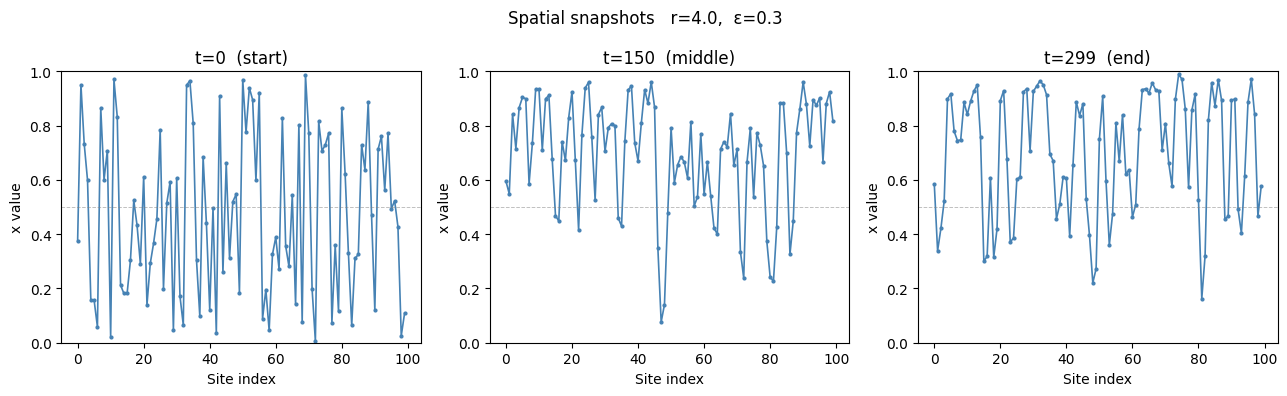

In [13]:
# Spatial snapshot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

snapshots = [0, T//2, T-1]          # early, middle, and late time
labels    = ['t=0  (start)', f't={T//2}  (middle)', f't={T-1}  (end)']

for ax, t_snap, label in zip(axes, snapshots, labels):
    ax.plot(history[t_snap, :],     # all sites at this one moment
            color='steelblue',
            linewidth=1.2,
            marker='o',
            markersize=2)
    ax.set_title(label)
    ax.set_xlabel('Site index')
    ax.set_ylabel('x value')
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='gray',   # reference line at x=0.5
               linestyle='--', linewidth=0.7, alpha=0.5)

plt.suptitle(f'Spatial snapshots   r={r},  ε={epsilon}')
plt.tight_layout()
plt.show()

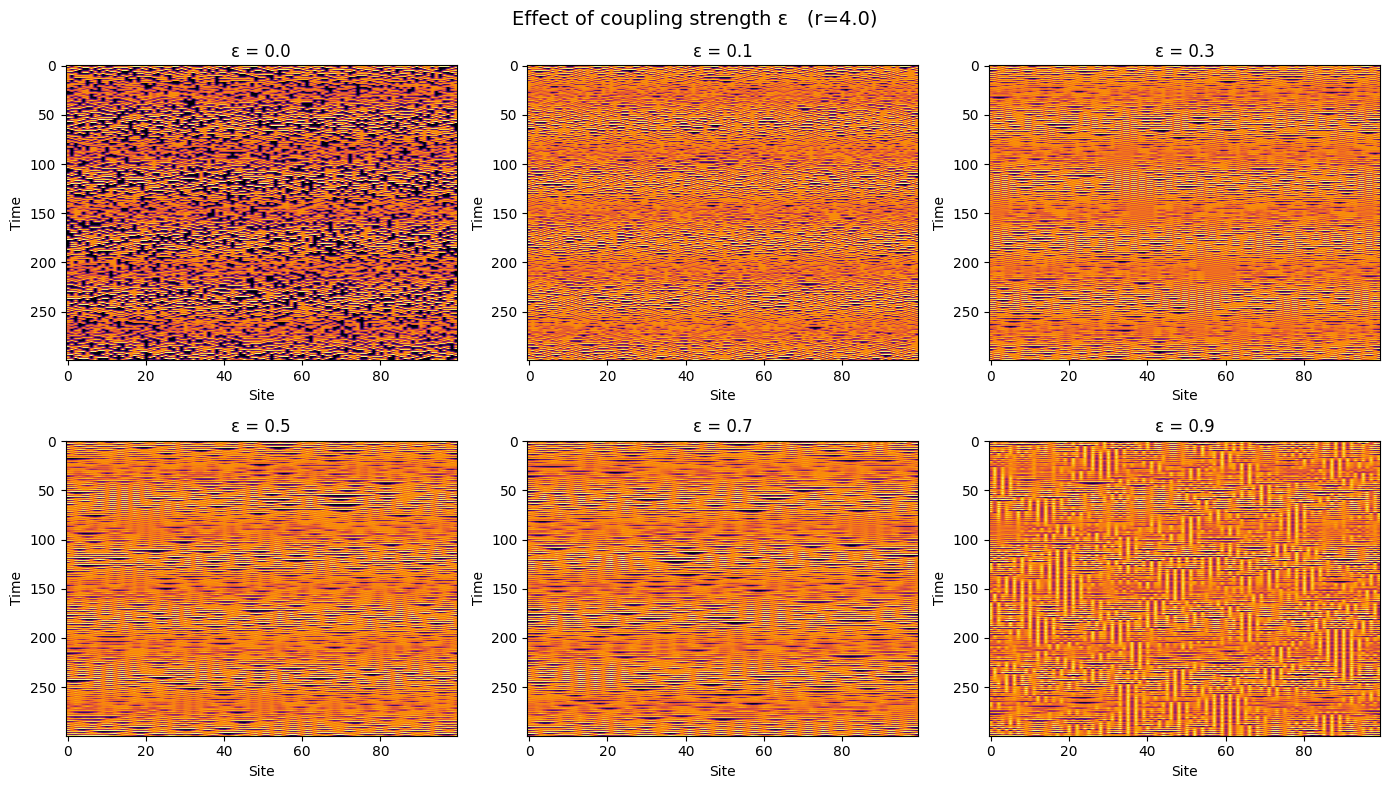

In [14]:
# Varying epsilon

epsilons = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()          # turn 2×3 grid into a flat list of 6 axes

for ax, eps in zip(axes, epsilons):

    # Re-run the CML with this epsilon
    np.random.seed(42)         # same seed every time — fair comparison!
    x = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = x

    for t in range(1, T):
        fx       = logistic(x, r)
        fx_left  = np.roll(fx,  1)
        fx_right = np.roll(fx, -1)
        x        = (1 - eps)*fx + (eps/2)*(fx_left + fx_right)
        hist[t]  = x

    # Plot
    ax.imshow(hist, aspect='auto', cmap='inferno',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'ε = {eps}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of coupling strength ε   (r={r})', fontsize=14)
plt.tight_layout()
plt.show()

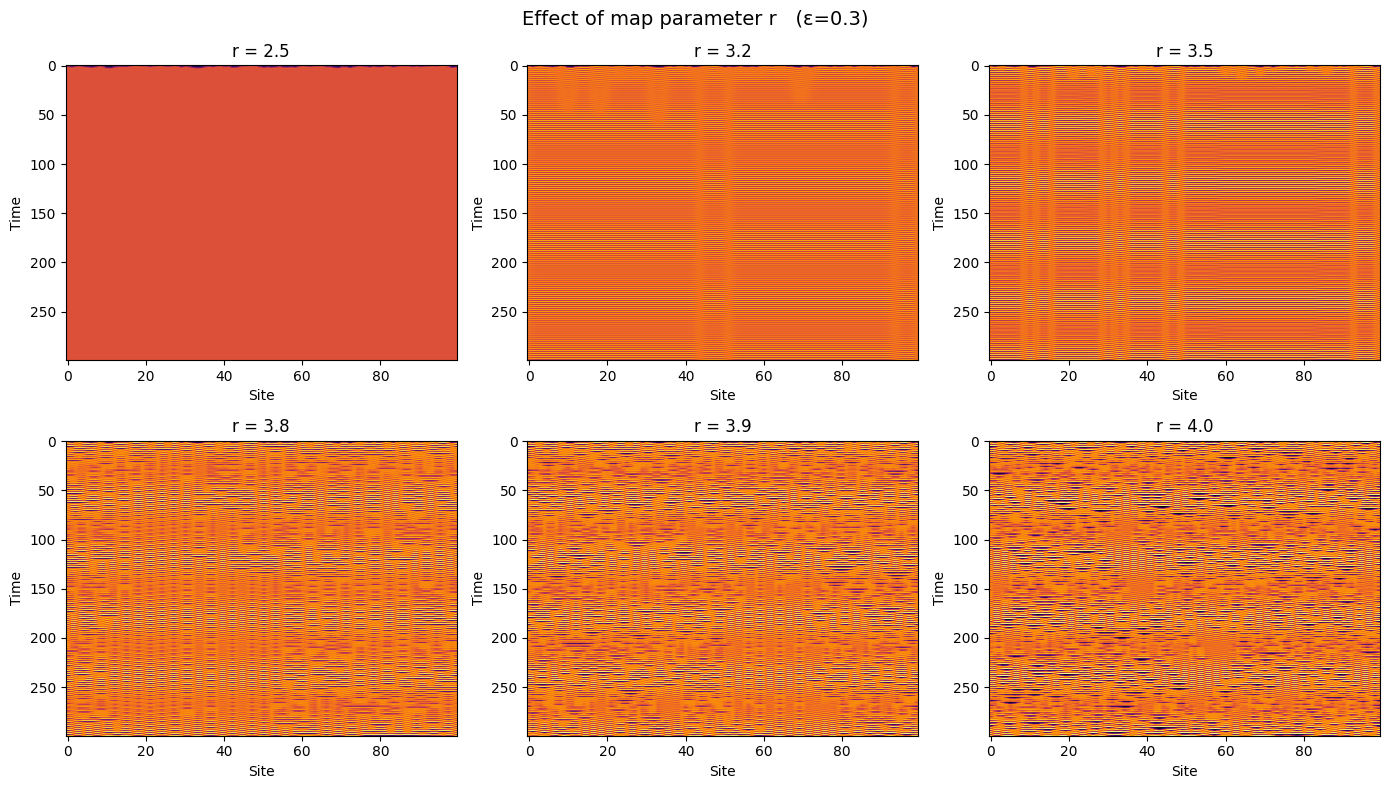

In [15]:
# varying r
r_values = [2.5, 3.2, 3.5, 3.8, 3.9, 4.0]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, r_val in zip(axes, r_values):

    np.random.seed(42)
    x = np.random.rand(N)
    hist = np.zeros((T, N))
    hist[0] = x

    for t in range(1, T):
        fx       = logistic(x, r_val)
        fx_left  = np.roll(fx,  1)
        fx_right = np.roll(fx, -1)
        x        = (1 - epsilon)*fx + (epsilon/2)*(fx_left + fx_right)
        hist[t]  = x

    ax.imshow(hist, aspect='auto', cmap='inferno',
              origin='upper', vmin=0, vmax=1)
    ax.set_title(f'r = {r_val}', fontsize=12)
    ax.set_xlabel('Site')
    ax.set_ylabel('Time')

plt.suptitle(f'Effect of map parameter r   (ε={epsilon})', fontsize=14)
plt.tight_layout()
plt.show()

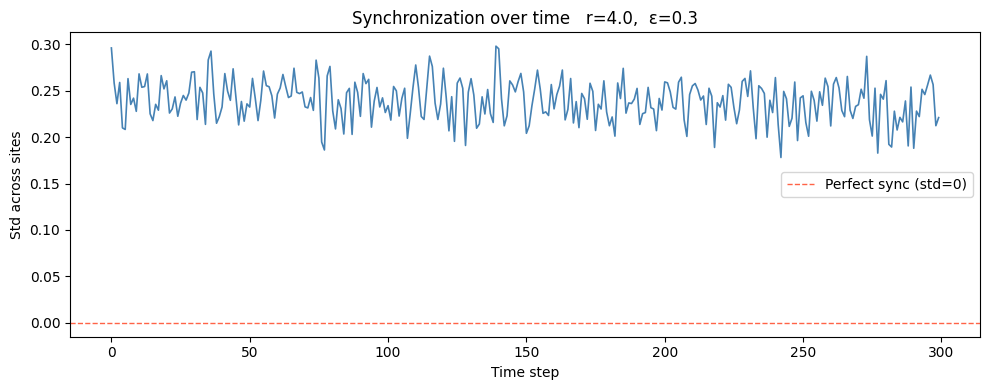

In [16]:
# synchronization
# Compute std across sites at every time step
sync = np.std(history, axis=1)     # axis=1 means "across columns (sites)"
                                    # result: one number per time step

plt.figure(figsize=(10, 4))
plt.plot(sync, color='steelblue', linewidth=1.2)
plt.axhline(0, color='tomato', linestyle='--',
            linewidth=1, label='Perfect sync (std=0)')
plt.xlabel('Time step')
plt.ylabel('Std across sites')
plt.title(f'Synchronization over time   r={r},  ε={epsilon}')
plt.legend()
plt.tight_layout()
plt.show()

##### Forest Fire

Simulation done. Shape: (200, 80, 80)
Value range:  0.0 → 1.0
Video saved → forest_fire_cml.mp4


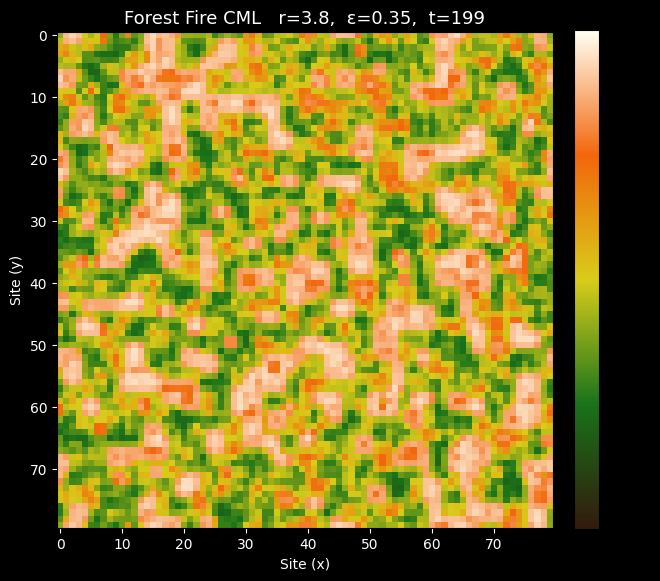

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap

# ─────────────────────────────────────────────────────────────────────
# PARAMETERS  (same style as your Module 3 setup)
# ─────────────────────────────────────────────────────────────────────

N       = 80      # Grid size: N×N lattice sites
T       = 200     # Number of frames to record
r       = 3.8     # Controls how chaotic/intense the fire cycle is
epsilon = 0.35    # Coupling = fire spread strength between neighbours

np.random.seed(42)

# ─────────────────────────────────────────────────────────────────────
# THE LOCAL MAP  (drop-in replacement for your logistic map)
# ─────────────────────────────────────────────────────────────────────

def fire_map(x, r):
    """
    Modified logistic map — same math as yours, same r parameter.
    This IS the logistic map. We're reusing your exact function.
    r=3.8 keeps it in the chaotic regime → realistic fire bursts.
    """
    return r * x * (1 - x)

# ─────────────────────────────────────────────────────────────────────
# INITIAL CONDITIONS
# ─────────────────────────────────────────────────────────────────────

x = np.random.rand(N, N)   # Every site gets a random fuel level

# Plant a fire seed in the centre — a small patch starts near ignition
cx, cy = N // 2, N // 2
x[cx-3:cx+3, cy-3:cy+3] = 0.95   # High value = about to ignite

# ─────────────────────────────────────────────────────────────────────
# 2D CML ENGINE  (direct extension of your 1D loop to 2D)
# ─────────────────────────────────────────────────────────────────────

history = np.zeros((T, N, N))   # Shape: (time, row, col)
history[0] = x

for t in range(1, T):
    fx = fire_map(x, r)                      # Apply map to every site

    # 4-neighbour coupling (up, down, left, right) — periodic boundaries
    fx_up    = np.roll(fx,  1, axis=0)       # neighbour above
    fx_down  = np.roll(fx, -1, axis=0)       # neighbour below
    fx_left  = np.roll(fx,  1, axis=1)       # neighbour to the left
    fx_right = np.roll(fx, -1, axis=1)       # neighbour to the right

    # CML update — exactly your formula, extended to 4 neighbours
    x = (1 - epsilon) * fx  +  (epsilon / 4) * (fx_up + fx_down +
                                                  fx_left + fx_right)
    history[t] = x

print("Simulation done. Shape:", history.shape)
print("Value range: ", history.min().round(3), "→", history.max().round(3))

# ─────────────────────────────────────────────────────────────────────
# CUSTOM COLORMAP  (makes it look like an actual fire)
# ─────────────────────────────────────────────────────────────────────
#
# x ≈ 0.0  →  dark brown  (burnt/bare ground)
# x ≈ 0.3  →  green       (recovering forest)
# x ≈ 0.6  →  yellow      (dry, about to ignite)
# x ≈ 0.8  →  orange      (catching fire)
# x ≈ 1.0  →  white-hot   (fully burning)

fire_colors = [
    (0.20, 0.10, 0.05),   # burnt ground — dark brown
    (0.10, 0.45, 0.10),   # healthy forest — green
    (0.85, 0.80, 0.10),   # dry/stressed — yellow
    (0.95, 0.40, 0.05),   # igniting — orange
    (1.00, 1.00, 0.95),   # peak fire — near white
]
fire_cmap = LinearSegmentedColormap.from_list("fire_forest", fire_colors, N=256)

# ─────────────────────────────────────────────────────────────────────
# ANIMATION
# ─────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

im = ax.imshow(
    history[0],
    cmap=fire_cmap,
    vmin=0, vmax=1,
    interpolation='nearest',
    origin='upper'
)

plt.colorbar(im, ax=ax, label='Fuel / Fire intensity', fraction=0.046, pad=0.04)
ax.set_xlabel('Site (x)', color='white')
ax.set_ylabel('Site (y)', color='white')
ax.tick_params(colors='white')
title = ax.set_title(f'Forest Fire CML   r={r},  ε={epsilon},  t=0',
                     color='white', fontsize=13)

def update(t):
    im.set_data(history[t])
    title.set_text(f'Forest Fire CML   r={r},  ε={epsilon},  t={t}')
    return [im, title]

ani = animation.FuncAnimation(
    fig,
    update,
    frames=T,
    interval=120,     # 60ms per frame ≈ smooth playback
    blit=True
)

# ─────────────────────────────────────────────────────────────────────
# SAVE AS MP4
# ─────────────────────────────────────────────────────────────────────

output_file = 'forest_fire_cml.mp4'
writer = animation.FFMpegWriter(fps=10,bitrate=1800)
ani.save(output_file, writer=writer, dpi=120)
print(f"Video saved → {output_file}")

plt.show()